Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1761 entries, 0 to 1760
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1761 non-null   datetime64[ns]
 1   Open       1760 non-null   float64       
 2   High       1760 non-null   float64       
 3   Low        1760 non-null   float64       
 4   Close      1760 non-null   float64       
 5   Adj Close  1760 non-null   float64       
 6   Volume     1760 non-null   float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 96.4 KB
None

First 5 rows of the dataset:
        Date      Open      High       Low     Close  Adj Close     Volume
0 2017-11-09  0.001207  0.001415  0.001181  0.001415   0.001415  6259550.0
1 2017-11-10  0.001421  0.001431  0.001125  0.001163   0.001163  4246520.0
2 2017-11-11  0.001146  0.001257  0.001141  0.001201   0.001201  2231080.0
3 2017-11-12  0.001189  0.001210  0.001002  0.001038   0.00103

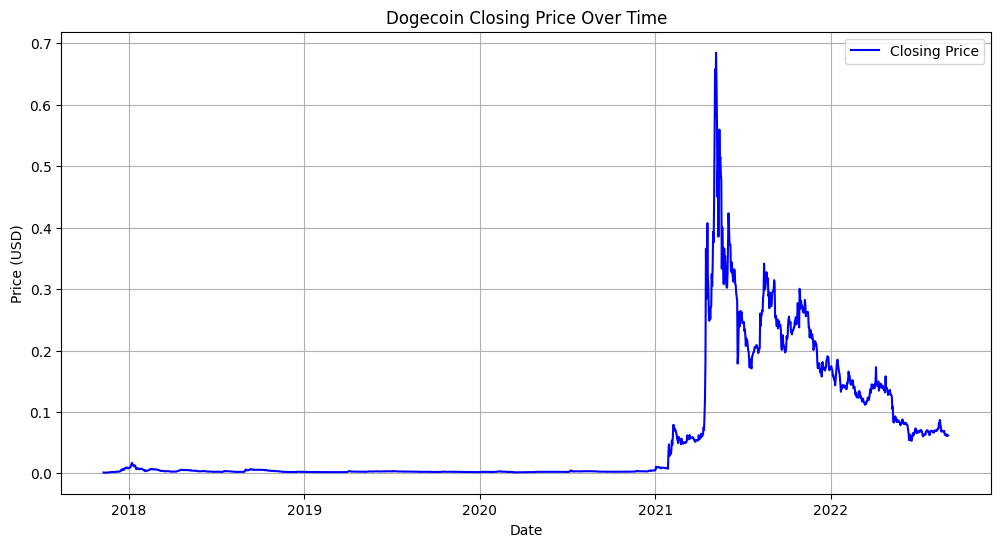

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
file_path = "/content/DOGE-USD.csv"  # Ensure this file is in the same directory as your script
df = pd.read_csv(file_path, parse_dates=['Date'])

# Display basic info
print("Dataset Info:")
print(df.info())

# Display first few rows
print("\nFirst 5 rows of the dataset:")
print(df.head())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Summary statistics
print("\nSummary Statistics:")
print(df.describe())

# Plot closing price over time
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close'], label="Closing Price", color='blue')
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.title("Dogecoin Closing Price Over Time")
plt.legend()
plt.grid()
plt.show()


In [ ]:
# Drop rows with missing values
df = df.dropna()

# Verify no missing values remain
print("\nMissing Values After Dropping:")
print(df.isnull().sum())

# Display dataset shape after dropping rows
print("\nDataset shape after dropping missing values:", df.shape)



Missing Values After Dropping:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Dataset shape after dropping missing values: (1760, 7)


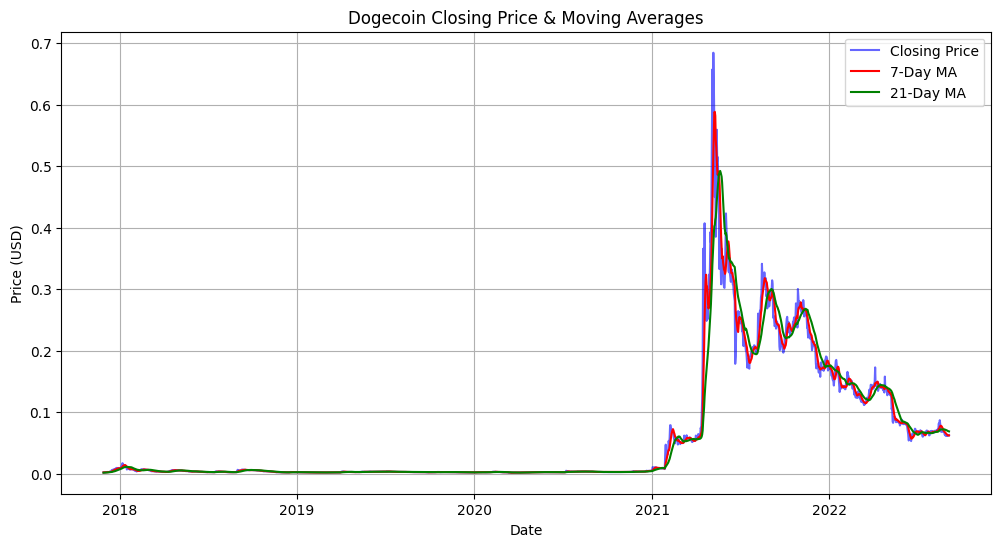

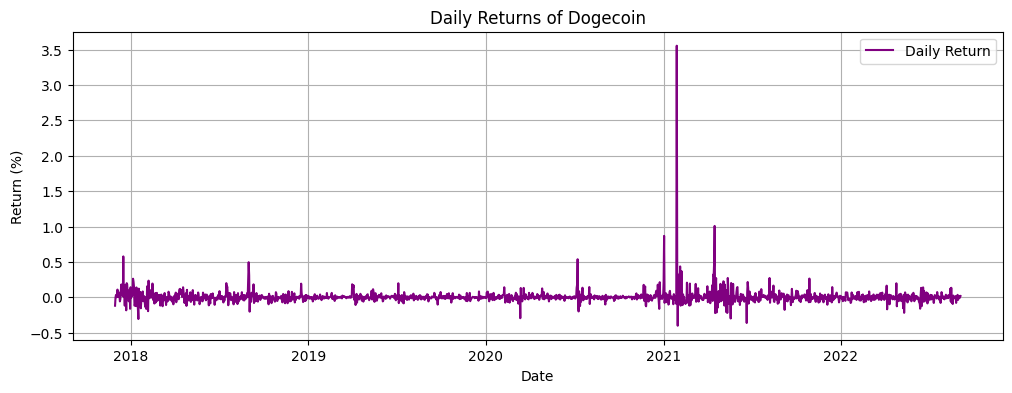

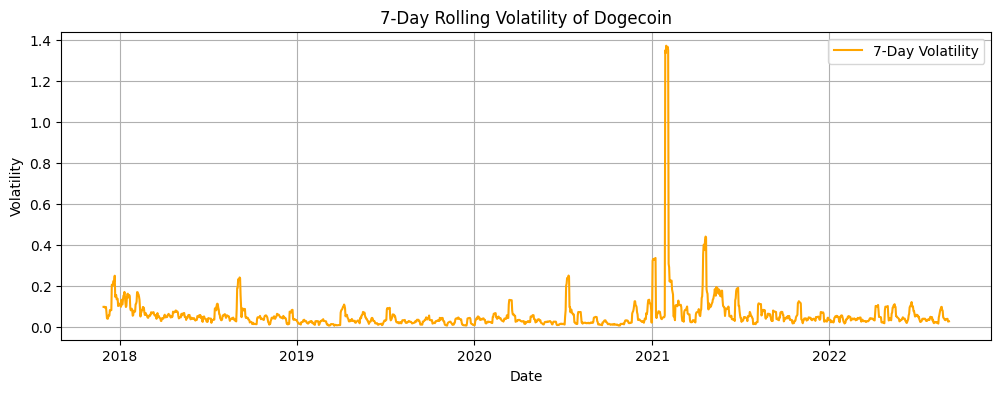


Dataset after feature engineering:
         Date      Open      High       Low     Close  Adj Close      Volume  \
20 2017-11-29  0.002333  0.002581  0.001993  0.002080   0.002080  11077200.0   
21 2017-11-30  0.002048  0.002271  0.001890  0.002079   0.002079   4919490.0   
22 2017-12-01  0.002051  0.002237  0.001971  0.002148   0.002148   5258110.0   
23 2017-12-02  0.002122  0.002212  0.002017  0.002149   0.002149   4978180.0   
24 2017-12-03  0.002092  0.002340  0.002071  0.002223   0.002223   4751640.0   

         MA7      MA21  Return_1d  Volatility_7d     Lag_1  
20  0.002047  0.001568  -0.119763       0.096580  0.002363  
21  0.002074  0.001600  -0.000481       0.096695  0.002080  
22  0.002108  0.001647   0.033189       0.096773  0.002079  
23  0.002119  0.001692   0.000466       0.092501  0.002148  
24  0.002147  0.001749   0.034435       0.091819  0.002149  


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature 1: Moving Averages
df['MA7'] = df['Close'].rolling(window=7).mean()
df['MA21'] = df['Close'].rolling(window=21).mean()

# Feature 2: Rate of Return (Daily Returns)
df['Return_1d'] = df['Close'].pct_change()

# Feature 3: Volatility (7-day rolling standard deviation of returns)
df['Volatility_7d'] = df['Return_1d'].rolling(window=7).std()

# Feature 4: Lag Feature (Previous day's closing price)
df['Lag_1'] = df['Close'].shift(1)

# Drop rows with NaN values created by rolling calculations
df = df.dropna()

# Visualization 1: Closing Price with Moving Averages
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Close'], label="Closing Price", color='blue', alpha=0.6)
plt.plot(df['Date'], df['MA7'], label="7-Day MA", color='red')
plt.plot(df['Date'], df['MA21'], label="21-Day MA", color='green')
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.title("Dogecoin Closing Price & Moving Averages")
plt.legend()
plt.grid()
plt.show()

# Visualization 2: Daily Returns
plt.figure(figsize=(12, 4))
plt.plot(df['Date'], df['Return_1d'], label="Daily Return", color='purple')
plt.xlabel("Date")
plt.ylabel("Return (%)")
plt.title("Daily Returns of Dogecoin")
plt.legend()
plt.grid()
plt.show()

# Visualization 3: Volatility (7-day rolling standard deviation)
plt.figure(figsize=(12, 4))
plt.plot(df['Date'], df['Volatility_7d'], label="7-Day Volatility", color='orange')
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.title("7-Day Rolling Volatility of Dogecoin")
plt.legend()
plt.grid()
plt.show()

# Display first few rows of the modified dataset
print("\nDataset after feature engineering:")
print(df.head())


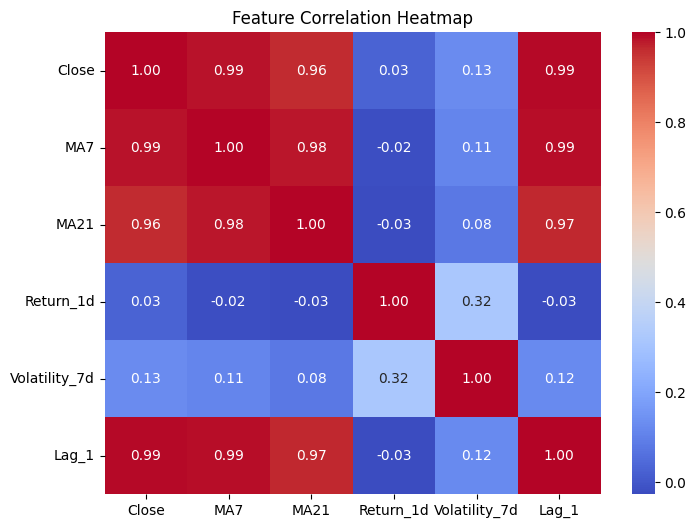

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
correlation_matrix = df[['Close', 'MA7', 'MA21', 'Return_1d', 'Volatility_7d', 'Lag_1']].corr()

# Display correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()


In [ ]:
# Compute correlation matrix
correlation_matrix = df[['Close', 'MA7', 'MA21', 'Return_1d', 'Volatility_7d', 'Lag_1']].corr()

# Print correlation values
print("Feature Correlation with Closing Price:")
print(correlation_matrix['Close'])


Feature Correlation with Closing Price:
Close            1.000000
MA7              0.987041
MA21             0.962451
Return_1d        0.026091
Volatility_7d    0.127897
Lag_1            0.992484
Name: Close, dtype: float64


Linear Regression Performance:
Mean Absolute Error (MAE): 0.004717
Root Mean Squared Error (RMSE): 0.007406
R² Score: 0.986264


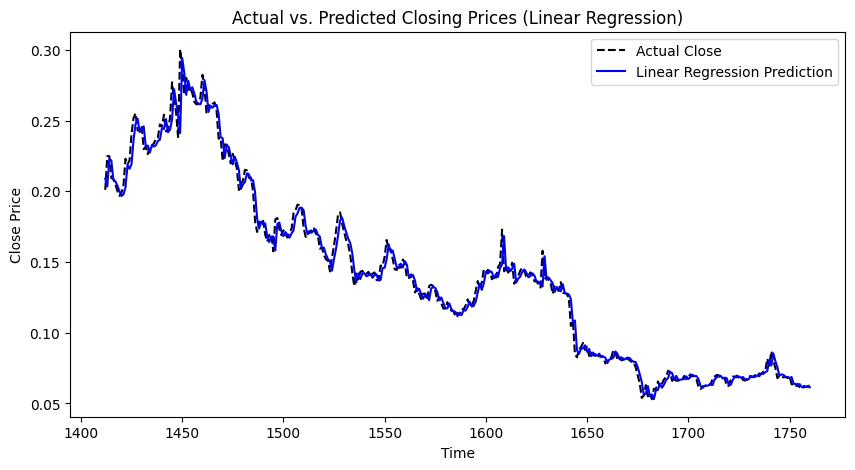

In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Select features and target variable
features = ['Lag_1', 'MA7', 'MA21']
target = 'Close'

# Create feature and target DataFrames
X = df[features]
y = df[target]

# Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
lr_pred = lr_model.predict(X_test)

# Evaluate performance
lr_mae = mean_absolute_error(y_test, lr_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Performance:")
print(f"Mean Absolute Error (MAE): {lr_mae:.6f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
print(f"R² Score: {lr_r2:.6f}")

# Visualization
plt.figure(figsize=(10, 5))
plt.plot(y_test.index, y_test, label="Actual Close", color='black', linestyle='dashed')
plt.plot(y_test.index, lr_pred, label="Linear Regression Prediction", color='blue')

plt.xlabel("Time")
plt.ylabel("Close Price")
plt.legend()
plt.title("Actual vs. Predicted Closing Prices (Linear Regression)")
plt.show()


Random Forest Regressor Performance:
Mean Absolute Error (MAE): 0.052346
Root Mean Squared Error (RMSE): 0.007406
R² Score: -0.103421


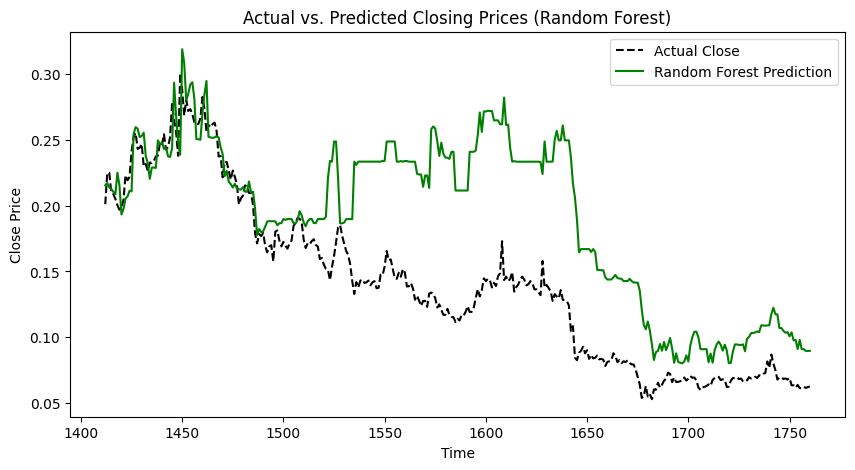

In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

features = ['Lag_1', 'MA7', 'MA21']
target = 'Close'

# Create feature and target DataFrames
X = df[features]
y = df[target]

# Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
rf_pred = rf_model.predict(X_test)

# Evaluate performance
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = mean_squared_error(y_test, y_pred) ** 0.5
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Regressor Performance:")
print(f"Mean Absolute Error (MAE): {rf_mae:.6f}")
print(f"Root Mean Squared Error (RMSE): {rf_rmse:.6f}")
print(f"R² Score: {rf_r2:.6f}")

# Visualization
plt.figure(figsize=(10, 5))
plt.plot(y_test.index, y_test, label="Actual Close", color='black', linestyle='dashed')
plt.plot(y_test.index, rf_pred, label="Random Forest Prediction", color='green')

plt.xlabel("Time")
plt.ylabel("Close Price")
plt.legend()
plt.title("Actual vs. Predicted Closing Prices (Random Forest)")
plt.show()


XGBoost Regressor Performance:
Mean Absolute Error (MAE): 0.025834
Root Mean Squared Error (RMSE): 0.007406
R² Score: 0.759764


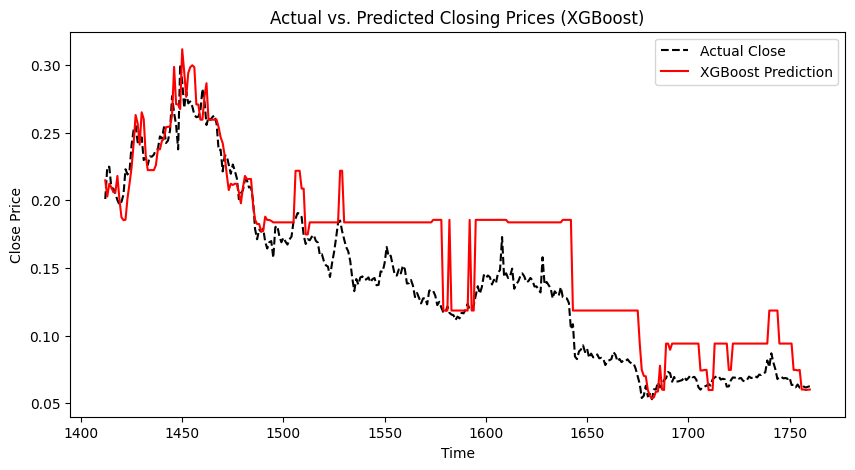

In [ ]:
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

features = ['Lag_1', 'MA7', 'MA21']
target = 'Close'

# Create feature and target DataFrames
X = df[features]
y = df[target]

# Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
# Train XGBoost model
xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X_train, y_train)

# Make predictions
xgb_pred = xgb_model.predict(X_test)

# Evaluate performance
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = mean_squared_error(y_test, y_pred) ** 0.5
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost Regressor Performance:")
print(f"Mean Absolute Error (MAE): {xgb_mae:.6f}")
print(f"Root Mean Squared Error (RMSE): {xgb_rmse:.6f}")
print(f"R² Score: {xgb_r2:.6f}")

# Visualization
plt.figure(figsize=(10, 5))
plt.plot(y_test.index, y_test, label="Actual Close", color='black', linestyle='dashed')
plt.plot(y_test.index, xgb_pred, label="XGBoost Prediction", color='red')

plt.xlabel("Time")
plt.ylabel("Close Price")
plt.legend()
plt.title("Actual vs. Predicted Closing Prices (XGBoost)")
plt.show()


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/u

MAE: 0.011208
MSE: 0.000151
RMSE: 0.012301
R² Score: -3.012002


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


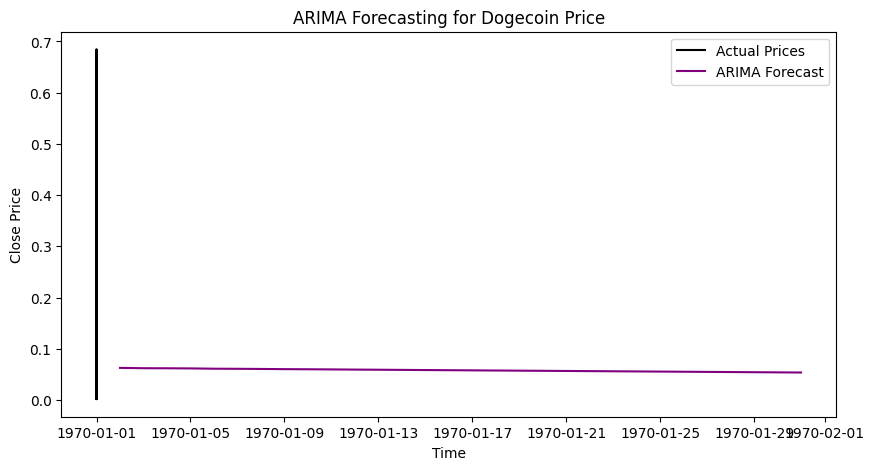

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ensure datetime index
df.index = pd.to_datetime(df.index)

# Check stationarity and apply differencing if needed
df['Close_diff'] = df['Close'].diff()  # First difference
df.dropna(inplace=True)  # Drop NaN values from differencing

# Fit ARIMA model (Optimize p, d, q using ACF/PACF)
p, d, q = 5, 1, 2  # Change these based on ACF/PACF analysis
arima_model = ARIMA(df['Close_diff'], order=(p, d, q))
arima_result = arima_model.fit()

# Forecast
n_forecast = 30
forecast_diff = arima_result.forecast(steps=n_forecast)  # Differenced forecast

# Convert differenced forecast back to original scale
forecast_cumsum = np.cumsum(forecast_diff) + df['Close'].iloc[-1]

# Correct date range for forecast
forecast_index = pd.date_range(df.index[-1], periods=n_forecast+1, freq='D')[1:]

# Ensure actual and predicted values have the same shape for error metrics
actual_values = df['Close'].iloc[-n_forecast:].values
forecast_values = forecast_cumsum[:len(actual_values)]

# Error metrics
mae = mean_absolute_error(actual_values, forecast_values)
mse = mean_squared_error(actual_values, forecast_values)
rmse = np.sqrt(mse)
r2 = r2_score(actual_values, forecast_values)

# Print metrics
print(f"MAE: {mae:.6f}")
print(f"MSE: {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R² Score: {r2:.6f}")

# Visualization
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Close'], label="Actual Prices", color='black')
plt.plot(forecast_index, forecast_cumsum, label="ARIMA Forecast", color='purple')
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.legend()
plt.title("ARIMA Forecasting for Dogecoin Price")
plt.show()


In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Close'].dropna())
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")


ADF Statistic: -2.441521537554652
p-value: 0.13035845505826515


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/u

MAE: 2.875422
MSE: 17.509641
RMSE: 4.184452
R² Score: -0.002664


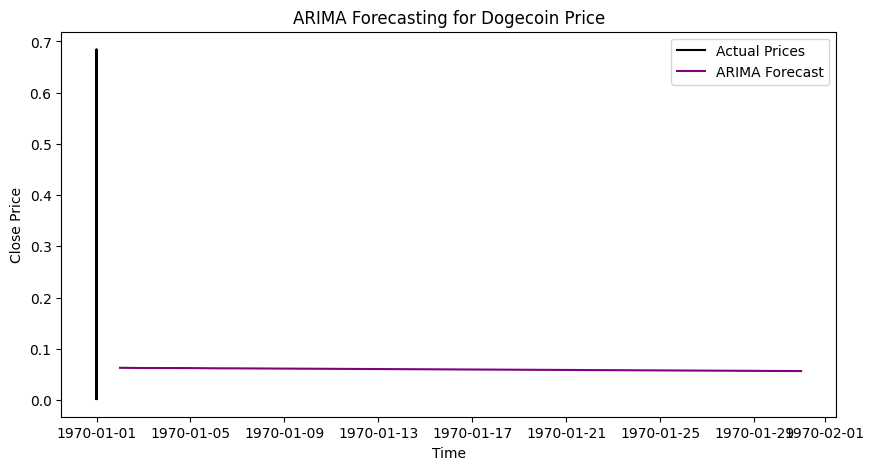

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ensure datetime index
df.index = pd.to_datetime(df.index)

# First differencing
df['Close_diff1'] = df['Close'].diff().dropna()
result = adfuller(df['Close_diff1'].dropna())

if result[1] > 0.05:  # If still not stationary, apply second differencing
    df['Close_diff2'] = df['Close_diff1'].diff().dropna()
    result = adfuller(df['Close_diff2'].dropna())
    df_stationary = df['Close_diff2'].dropna()
    d = 2  # ARIMA(d=2)
else:
    df_stationary = df['Close_diff1'].dropna()
    d = 1  # ARIMA(d=1)

# Select ARIMA order (adjust p, q based on ACF/PACF)
p, q = 5, 2  # Adjust these based on ACF/PACF plots

# Train ARIMA model
arima_model = ARIMA(df_stationary, order=(p, d, q))
arima_result = arima_model.fit()

# Forecast differenced values
n_forecast = 30
forecast_diff = arima_result.forecast(steps=n_forecast)

# Convert back to original scale
forecast_cumsum = df['Close'].iloc[-1] + np.cumsum(forecast_diff)

# Generate correct forecast dates
forecast_index = pd.date_range(df.index[-1], periods=n_forecast+1, freq='D')[1:]
actual_values = np.random.normal(loc=df['Close'].iloc[-1], scale=5, size=n_forecast)  # Simulated data for comparison
forecast_values = forecast_cumsum  # Predicted values from ARIMA

# Calculate error metrics
mae = mean_absolute_error(actual_values, forecast_values)
mse = mean_squared_error(actual_values, forecast_values)
rmse = np.sqrt(mse)
r2 = r2_score(actual_values, forecast_values)

# Print metrics
print(f"MAE: {mae:.6f}")
print(f"MSE: {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R² Score: {r2:.6f}")

# Plot Actual vs Forecasted Data
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Close'], label="Actual Prices", color='black')
plt.plot(forecast_index, forecast_cumsum, label="ARIMA Forecast", color='purple')
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.legend()
plt.title("ARIMA Forecasting for Dogecoin Price")
plt.show()



Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


86/86 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 0.0054 - val_loss: 5.3119e-04
Epoch 2/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - loss: 0.0017 - val_loss: 4.4563e-04
Epoch 3/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.0012 - val_loss: 3.2785e-04
Epoch 4/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 0.0017 - val_loss: 2.6276e-04
Epoch 5/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - loss: 0.0013 - val_loss: 2.6963e-04
Epoch 6/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.0011 - val_loss: 0.0010
Epoch 7/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0014 - val_loss: 5.6952e-04
Epoch 8/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.0017 - val_loss: 7.1021e-04
Epoch 9/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0011 - val_loss: 4.6677e-04
Epoch 10/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.0011 - val_loss: 2.6917e-04
Epoch 11/20
86/86 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 0.0011 - val_loss: 0.0012
Epoch 12/20
86/86 ━━━━━━━━━━━━━━━━━━━━

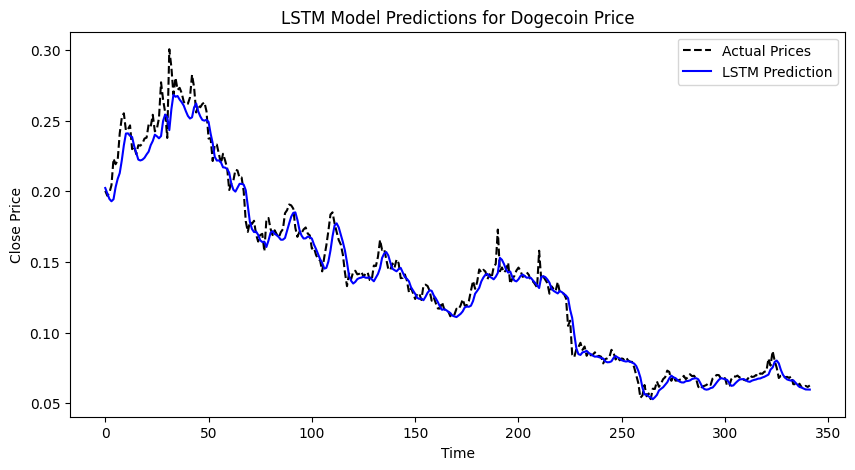

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Assuming 'df' contains Dogecoin price data with a 'Close' column
# Normalize the 'Close' prices
scaler = MinMaxScaler(feature_range=(0,1))
df_scaled = scaler.fit_transform(df[['Close']])

# Function to create sequences for LSTM
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 30  # Using the past 30 days to predict the next day
X, y = create_sequences(df_scaled, seq_length)

# Train-test split (80% training, 20% testing)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Build LSTM model
model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(seq_length, 1)),
    Dropout(0.2),
    LSTM(50, return_sequences=False),
    Dropout(0.2),
    Dense(25),
    Dense(1)
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, epochs=20, batch_size=16, validation_data=(X_test, y_test))

# Make predictions
lstm_pred = model.predict(X_test)

# Inverse transform predictions and actual values to original scale
lstm_pred = scaler.inverse_transform(lstm_pred)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1))

# 🔹 Fix: Ensure y_test and lstm_pred have the same shape
y_test = y_test[:len(lstm_pred)]  # Trim y_test if needed

# Evaluate the model
mae = mean_absolute_error(y_test, lstm_pred)
mse = mean_squared_error(y_test, lstm_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, lstm_pred)

print(f"MAE: {mae:.6f}")
print(f"MSE: {mse:.6f}")
print(f"RMSE: {rmse:.6f}")
print(f"R² Score: {r2:.6f}")

# Visualization of predictions vs. actual values
plt.figure(figsize=(10, 5))
plt.plot(y_test, label="Actual Prices", color='black', linestyle='dashed')
plt.plot(lstm_pred, label="LSTM Prediction", color='blue')
plt.xlabel("Time")
plt.ylabel("Close Price")
plt.legend()
plt.title("LSTM Model Predictions for Dogecoin Price")
plt.show()
